# 02 · Growing a Tree

Make the single split **recursive**: apply the same best-split search to each group, then again, and again. Watch the staircase boundary refine and the tree structure grow as depth increases.

**Artifacts:** `outputs/figures/02_*.png`, `outputs/data/02_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config import load_settings
from src.datasets import moons
from src.tree.classifier import DecisionTreeClassifier
from src.evaluation import accuracy, plot_decision_boundary, train_test_accuracy_vs_depth
from src.visualisation import plot_tree, export_text
from src.outputs import save_figure, save_json

SEED = load_settings().seed
RES = 200
X, y = moons(n_samples=400, noise=0.2, seed=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED)
print('train:', X_tr.shape, '| test:', X_te.shape)

train: (280, 2) | test: (120, 2)


## The data — interleaving moons
A curved boundary. A staircase of axis-aligned cuts will have to approximate it.

PosixPath('/workspaces/decision_trees_101/outputs/figures/02_moons.png')

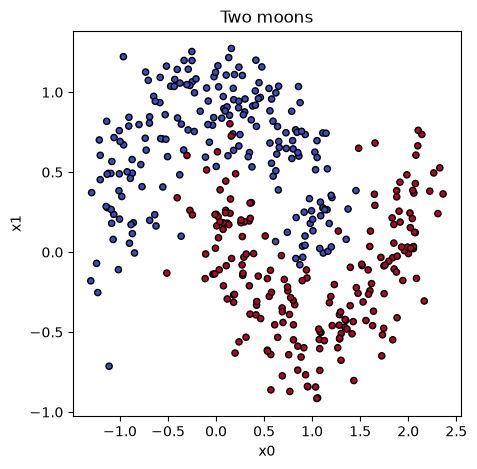

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
ax.set(title='Two moons', xlabel='x0', ylabel='x1')
save_figure(fig, '02_moons')

## Depth by depth
A stump (depth 1), a small tree (depth 3), and a deep tree (depth 8). The staircase approximates the curve better as depth grows.

PosixPath('/workspaces/decision_trees_101/outputs/figures/02_depths.png')

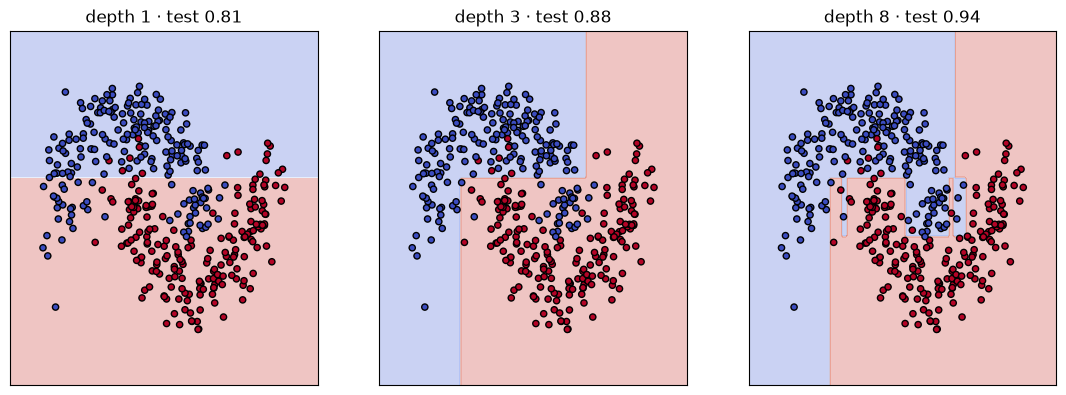

In [3]:
depths = [1, 3, 8]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, d in zip(axes, depths, strict=True):
    clf = DecisionTreeClassifier(max_depth=d).fit(X_tr, y_tr)
    acc = accuracy(y_te, clf.predict(X_te))
    plot_decision_boundary(clf, X, y, ax=ax, resolution=RES, title=f'depth {d} · test {acc:.2f}')
save_figure(fig, '02_depths')

## The tree structure alongside
The depth-3 tree as a node-link diagram — the same object, drawn as the questions it asks.

|--- x1 <= 0.448
|   |--- x0 <= -0.568
|   |   |--- value: [1.0, 0.0]
|   |--- x0 >  -0.568
|   |   |--- x1 <= -0.080
|   |   |   |--- value: [0.0, 1.0]
|   |   |--- x1 >  -0.080
|   |   |   |--- value: [0.315, 0.685]
|--- x1 >  0.448
|   |--- x0 <= 1.321
|   |   |--- x1 <= 0.730
|   |   |   |--- value: [0.949, 0.051]
|   |   |--- x1 >  0.730
|   |   |   |--- value: [1.0, 0.0]
|   |--- x0 >  1.321
|   |   |--- value: [0.0, 1.0]


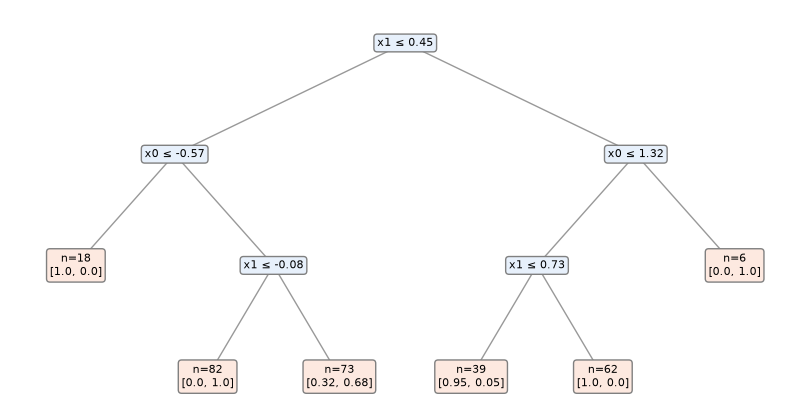

In [4]:
clf3 = DecisionTreeClassifier(max_depth=3).fit(X_tr, y_tr)
ax = plot_tree(clf3)
save_figure(ax.figure, '02_tree_depth3')
print(export_text(clf3))

## When does deeper stop helping?
Train accuracy keeps climbing; test accuracy peaks then sags. That gap is the subject of notebook 05.

PosixPath('/workspaces/decision_trees_101/outputs/figures/02_accuracy_vs_depth.png')

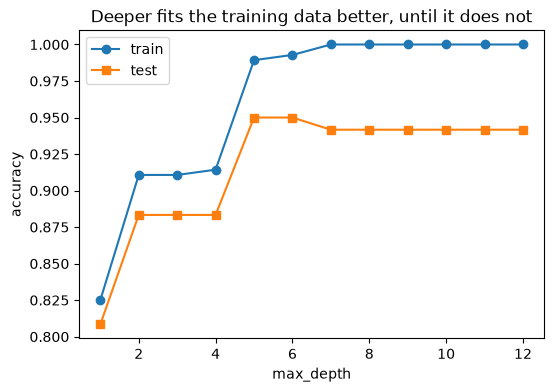

In [5]:
rows = train_test_accuracy_vs_depth(X_tr, y_tr, X_te, y_te, depths=range(1, 13))
ds = [r['depth'] for r in rows]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ds, [r['train'] for r in rows], marker='o', label='train')
ax.plot(ds, [r['test'] for r in rows], marker='s', label='test')
ax.set(xlabel='max_depth', ylabel='accuracy', title='Deeper fits the training data better, until it does not')
ax.legend()
save_figure(fig, '02_accuracy_vs_depth')

In [6]:
save_json({'seed': SEED, 'accuracy_vs_depth': rows}, '02_accuracy_vs_depth')
save_json({'depth3_structure': export_text(clf3)}, '02_tree_depth3_text')
print('saved 02_accuracy_vs_depth.json, 02_tree_depth3_text.json')

saved 02_accuracy_vs_depth.json, 02_tree_depth3_text.json


## Takeaway
Recursion is the whole trick: the same greedy split, applied to each child. Depth is the dial between a coarse staircase and one fine enough to trace the moons — and, eventually, fine enough to memorize.